In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the path to your data
file_path = os.path.join('..', 'data', 'sudan.csv')

# Load and prepare the date index
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str), format='%Y%j')
df.set_index('Date', inplace=True)

# Preview the data
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
Date,,,,,,,,,,,,
2015-01-01,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
2015-01-02,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2015-01-03,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
2015-01-04,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
2015-01-05,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


In [3]:
# Check for missing values
print("Missing Values Check - Sudan:")
print(df.isnull().sum())

# Statistical Summary
print("\nStatistical Summary - Sudan:")
display(df.describe())

Missing Values Check - Sudan:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

Statistical Summary - Sudan:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000


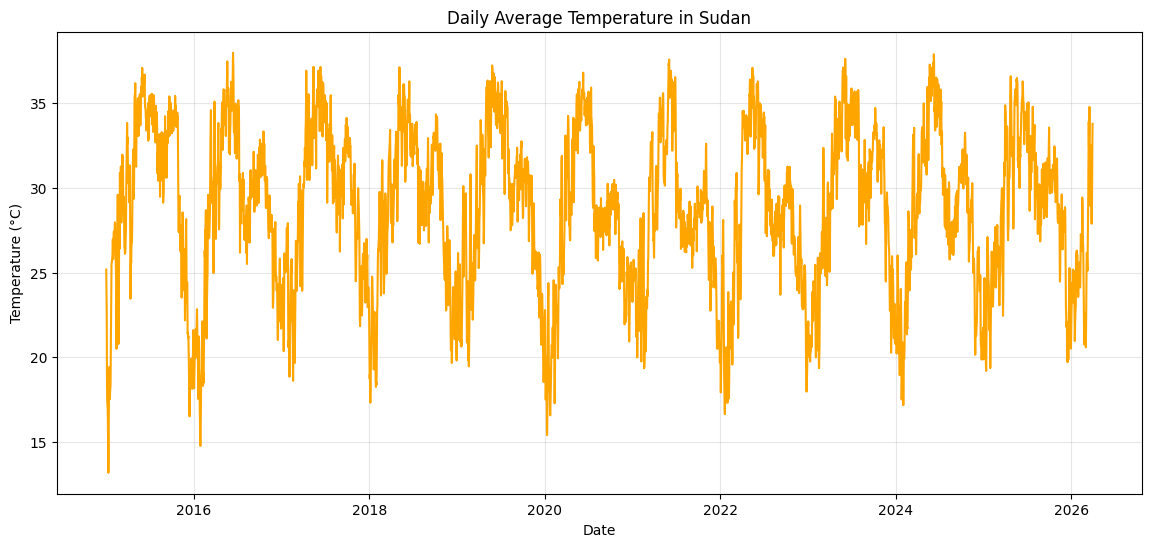

In [4]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x=df.index, y='T2M', color='orange')
plt.title('Daily Average Temperature in Sudan')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

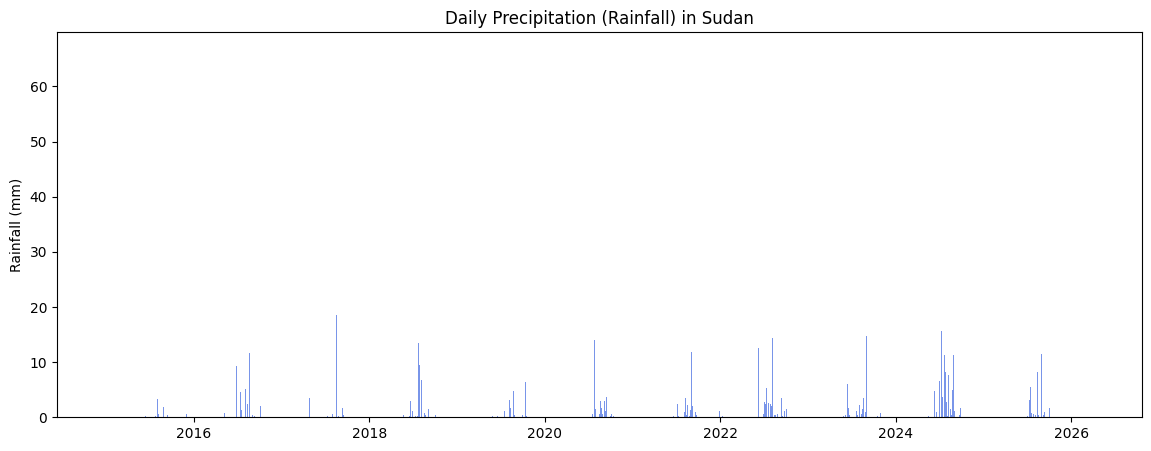

In [5]:
plt.figure(figsize=(14, 5))
plt.bar(df.index, df['PRECTOTCORR'], color='royalblue', alpha=0.7)
plt.title('Daily Precipitation (Rainfall) in Sudan')
plt.ylabel('Rainfall (mm)')
plt.show()

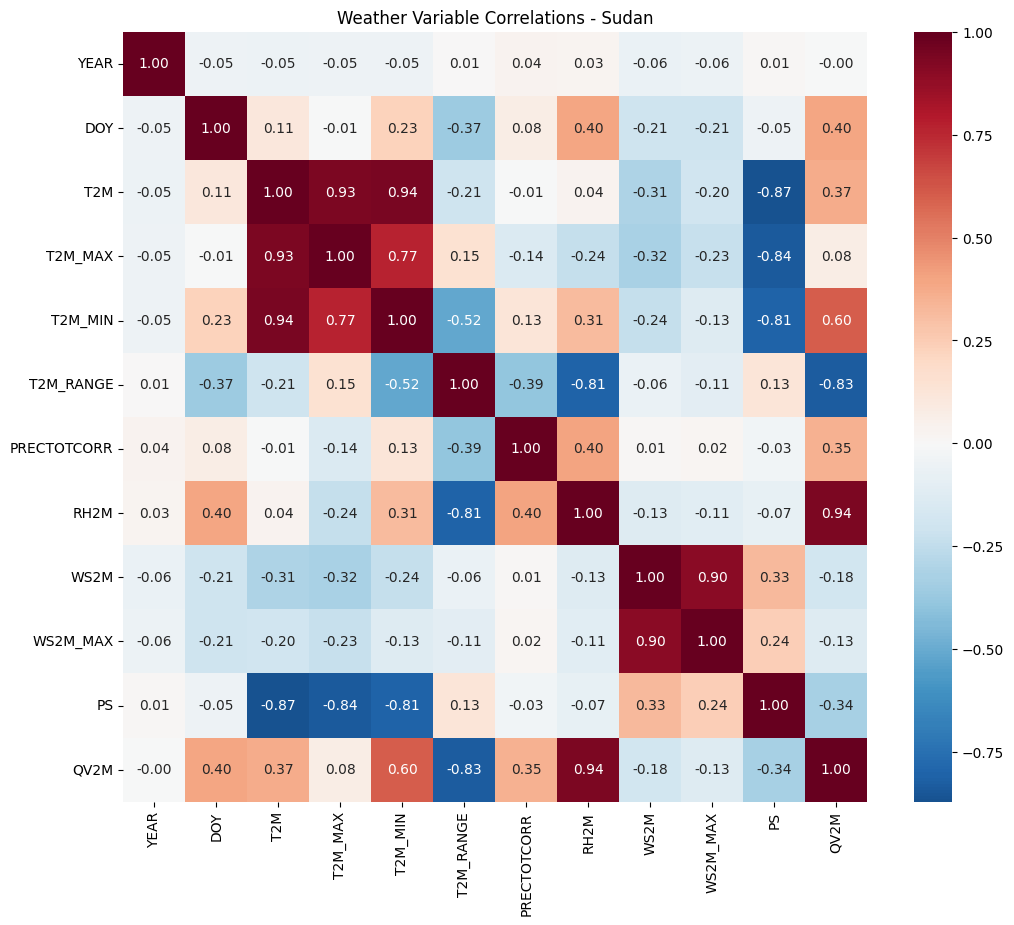

In [6]:
plt.figure(figsize=(12, 10))
# We calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Weather Variable Correlations - Sudan')
plt.show()

In [7]:
import numpy as np
from scipy import stats

# 1. Load and add Country column
df = pd.read_csv('../data/sudan.csv')
df['Country'] = 'Sudan'

# 2. Convert YEAR/DOY to Date and extract Month
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df.set_index('Date', inplace=True)

# 3. Handle NASA Sentinel values (-999)
df.replace(-999, np.nan, inplace=True)

# 4. Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")
df.drop_duplicates(inplace=True)

# 5. Missing value report
missing_pct = (df.isna().sum() / len(df)) * 100
print("\nMissing Values Percentage:")
print(missing_pct)

Duplicates found: 0

Missing Values Percentage:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Month          0.0
dtype: float64


In [8]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[cols_to_check].dropna()))

# Flagging rows where Z > 3
outliers = (z_scores > 3).all(axis=1)
print(f"Number of outlier rows flagged in Sudan: {outliers.sum()}")

# Decision: We will retain them for now as weather extremes (like heatwaves) 
# are important for climate study, but we acknowledge them.

Number of outlier rows flagged in Sudan: 0


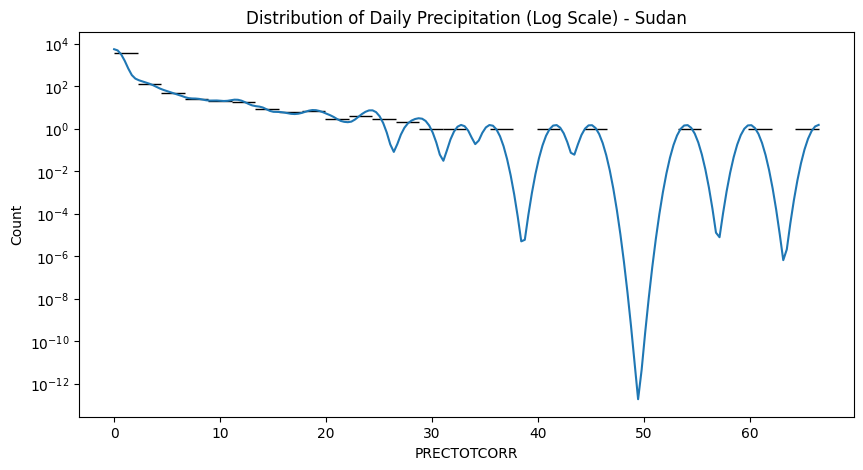

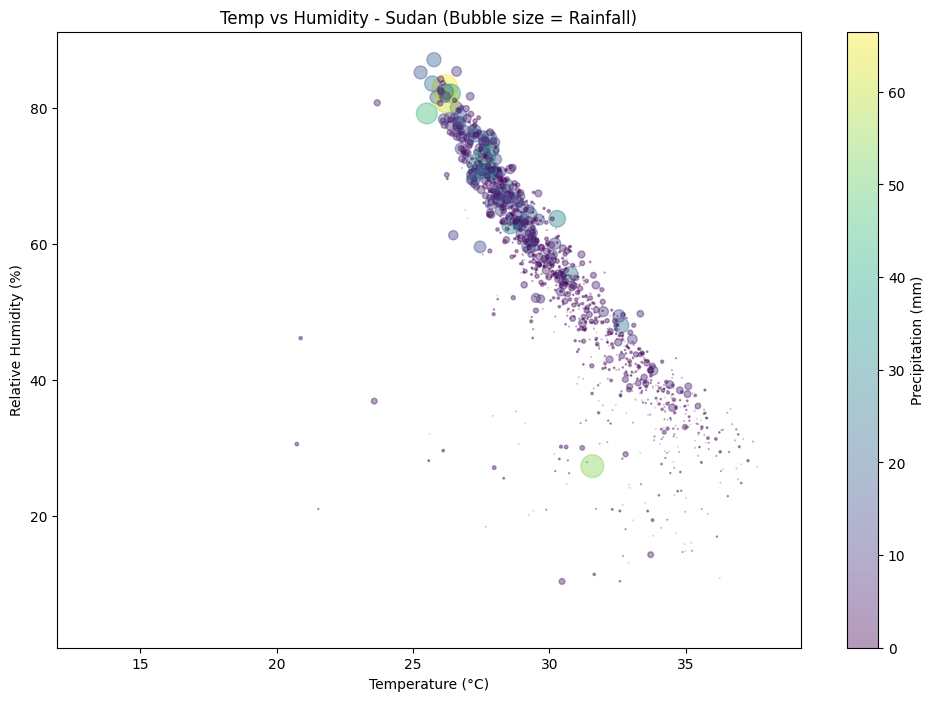

In [9]:
# Histogram of Rainfall (Log scale)
plt.figure(figsize=(10, 5))
sns.histplot(df['PRECTOTCORR'], bins=30, kde=True, log_scale=(False, True))
plt.title('Distribution of Daily Precipitation (Log Scale) - Sudan')
plt.show()

# Bubble Chart: Temp vs Humidity (Size = Rain)
plt.figure(figsize=(12, 8))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*5, alpha=0.4, c=df['PRECTOTCORR'], cmap='viridis')
plt.colorbar(label='Precipitation (mm)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Temp vs Humidity - Sudan (Bubble size = Rainfall)')
plt.show()

In [10]:
# Create the directory if it doesn't exist
os.makedirs('../data', exist_ok=True)

# Export
df.to_csv('../data/sudan_clean.csv')
print("Cleaned data exported to data/sudan_clean.csv")

Cleaned data exported to data/sudan_clean.csv


Final Analysis: 
Sudan Climate Trends
The Trend: Sudan shows the highest thermal intensity of the five countries, with an average temperature of 28.76°C and extreme peaks reaching 45.96°C. The line plot exhibits sharp seasonal spikes. While the cycles are regular, the sheer height of the summer peaks indicates a hyper-arid environment where heat stress is a persistent annual trend.

The Connection: Unlike the tropical countries, Sudan's rainfall is most strongly tied to Relative Humidity (RH2M) with a correlation of 0.40, but its overall precipitation is the lowest (mean of only 0.64mm). The heatmap shows a very strong negative correlation between Surface Pressure (PS) and Temperature (-0.87), showing how thermal lows drive the local weather dynamics.

The Outliers: The Z-score test flagged 0 rows as outliers across the entire feature set. We have retained the maximum temperature of 45.96°C and the rare 66.49mm rainfall event because these represent the "worst-case scenarios" for drought and flash-flood planning. In a desert climate, these extremes are the most scientifically valuable data points.